In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [4]:
# Create a state for graph

class State(TypedDict):
    text: str
    upper_text: str
    word_count: int

In [5]:
# create nodes

def upper_text_node(state: State):
    return {
        "upper_text": state["text"].upper()
    }
    
def word_count_node(state: State):
    return {
        "word_count": len(state["text"].split())
    }

In [10]:
# create graph

builder = StateGraph(State)

builder.add_node("upper_text", upper_text_node)
builder.add_node("word_count", word_count_node)

builder.add_edge(START, "upper_text")
builder.add_edge("upper_text", "word_count")
builder.add_edge("word_count", END)

graph = builder.compile()

In [12]:
graph.invoke({"text": "Hello World"})

{'text': 'Hello World', 'upper_text': 'HELLO WORLD', 'word_count': 2}

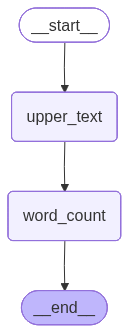

In [20]:
# visualize the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))